In [1]:
import os
import rasterio
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rasterio.plot import show
from matplotlib.colors import TwoSlopeNorm

RESULTS = r"./results"

# 1 km hex grid (GeoJSON you saved)
hexes = gpd.read_file(os.path.join(RESULTS, "AOI_hexes_1km.geojson"))

# RESTREND bi-weekly output
retrend_bw = pd.read_csv(os.path.join(RESULTS, "RESTREND_hex1km_biweekly_NDVI_vs_Rain.csv"))

# MK/Sen trend rasters (NDVI, OSAVI, NDWI, RVI)
mk_files = {
    "NDVI": os.path.join(RESULTS, "NDVI_MK_SenSlope_Z_P.tif"),
    "OSAVI": os.path.join(RESULTS, "OSAVI_MK_SenSlope_Z_P.tif"),
    "NDWI": os.path.join(RESULTS, "NDWI_MK_SenSlope_Z_P.tif"),
    "RVI": os.path.join(RESULTS, "RVI_MK_SenSlope_Z_P.tif"),
}

# Seasonal Δ rasters
delta_files = {
    "NDVI": os.path.join(RESULTS, "Delta_NDVI_2023-24_minus_2022-23.tif"),
    "NDWI": os.path.join(RESULTS, "Delta_NDWI_2023-24_minus_2022-23.tif"),
    "RVI": os.path.join(RESULTS, "Delta_RVI_2023-24_minus_2022-23.tif"),
}


C:\Users\user\AppData\Local\Temp\ipykernel_28592\241791736.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


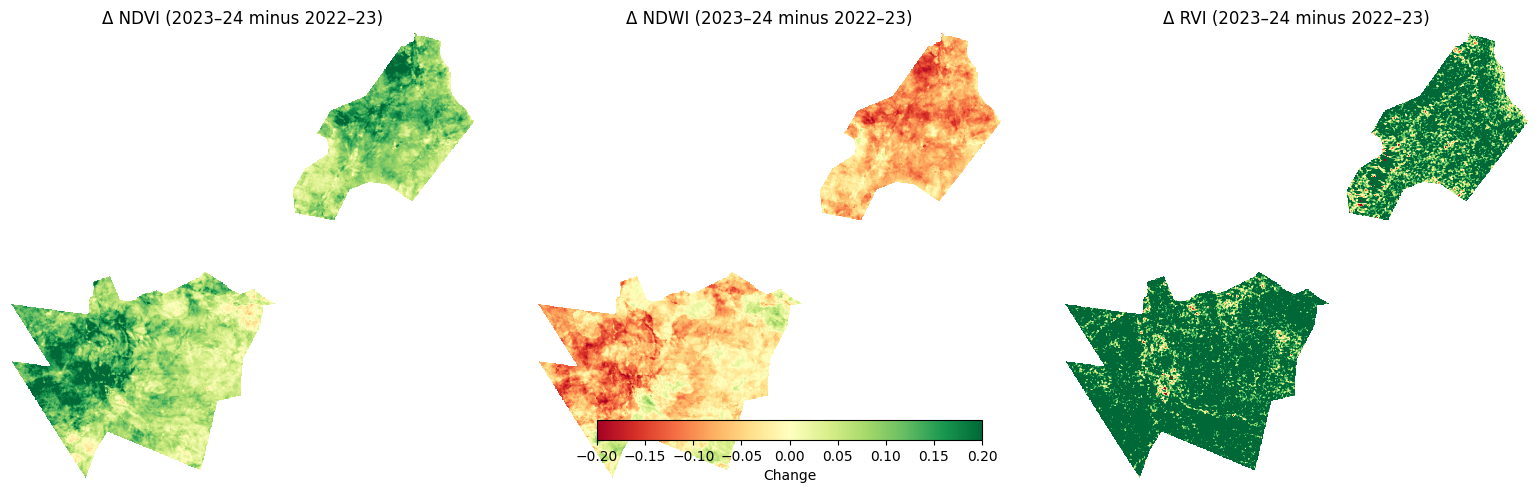

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))
for i, (metric, path) in enumerate(delta_files.items()):
    with rasterio.open(path) as src:
        arr = src.read(1)
        arr[arr==src.nodata] = np.nan
        norm = TwoSlopeNorm(vmin=-0.2, vcenter=0, vmax=0.2)
        im = axes[i].imshow(arr, cmap="RdYlGn", norm=norm)
        axes[i].set_title(f"Δ {metric} (2023–24 minus 2022–23)")
        axes[i].axis("off")
fig.colorbar(im, ax=axes, orientation="horizontal", fraction=0.05, pad=0.05, label="Change")
plt.tight_layout()
plt.show()


In [4]:
mk_files = {
    "RVI": os.path.join(RESULTS, "RVI_MK_SenSlope_Z_P.tif")
}

C:\Users\user\AppData\Local\Temp\ipykernel_18156\2489053488.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


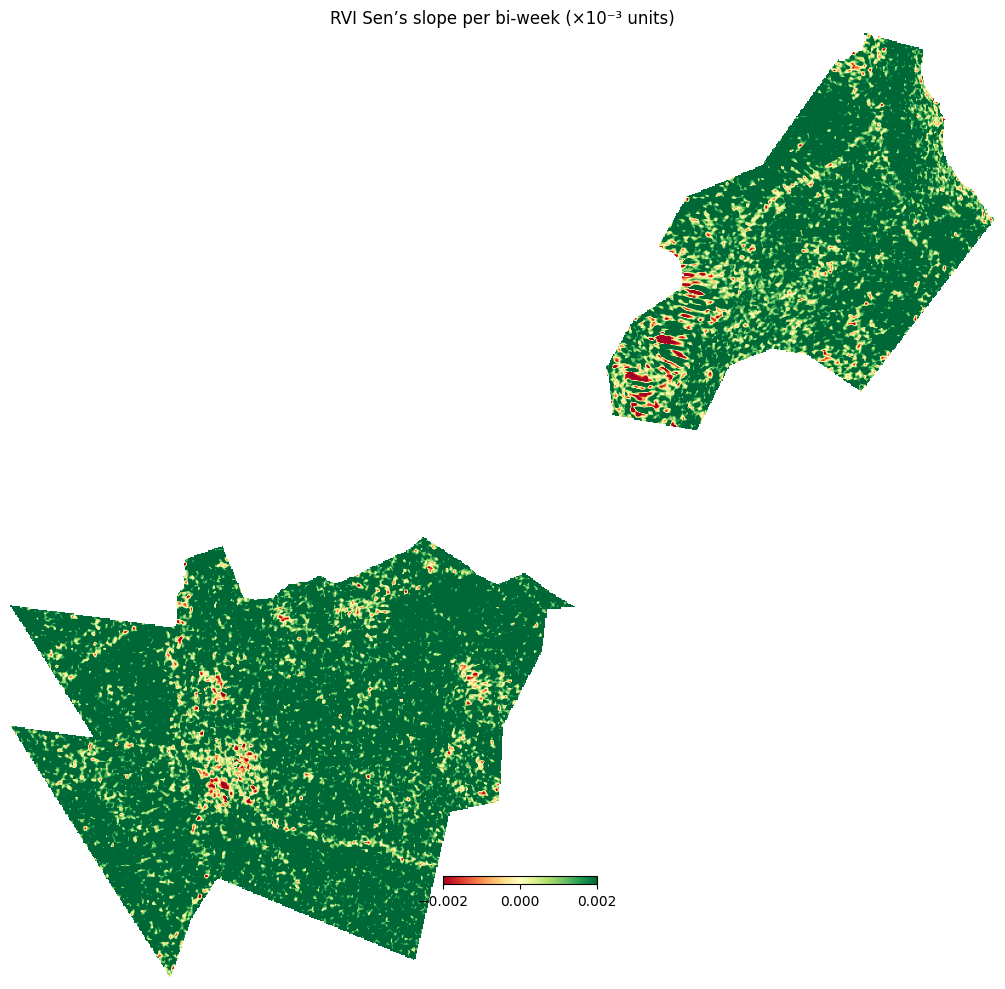

'\n\nPositive slope → gradual increase (greening/moistening).\n\nNegative slope → decline over 2022–24.\n\nNDWI↓ with NDVI stable → drying bofedales;\nNDVI↓ + RVI↓ → loss of vegetation density/structure.\n'

In [6]:
# create one subplot per metric to avoid Axes vs ndarray mismatch
n_metrics = len(mk_files)
fig, axes = plt.subplots(1, n_metrics, figsize=(14,10))
axes = np.atleast_1d(axes)
axes_flat = np.array(axes).ravel()

for ax, (metric, path) in zip(axes_flat, mk_files.items()):
    with rasterio.open(path) as src:
        slope = src.read(1).astype(float)
        slope[slope == src.nodata] = np.nan
        im = ax.imshow(slope, cmap="RdYlGn", vmin=-0.002, vmax=0.002)
        ax.set_title(f"{metric} Sen’s slope per bi-week (×10⁻³ units)")
        ax.axis("off")

fig.colorbar(im, ax=axes_flat.tolist(), orientation="horizontal", fraction=0.01, pad=0.05)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "MK_SenSlope_all_metrics.png"), dpi=300)
plt.show()


'''

Positive slope → gradual increase (greening/moistening).

Negative slope → decline over 2022–24.

NDWI↓ with NDVI stable → drying bofedales;
NDVI↓ + RVI↓ → loss of vegetation density/structure.
'''



In [42]:
import numpy as np
import rasterio

with rasterio.open(os.path.join(RESULTS, "NDVI_MK_SenSlope_Z_P.tif")) as src:
    slope = src.read(1).astype(float)
    slope[slope==src.nodata] = np.nan

print("Sen slope (bi-weekly) stats:")
print(f"Min: {np.nanmin(slope):.4f}, Max: {np.nanmax(slope):.4f}, Median: {np.nanmedian(slope):.4f}")

Sen slope (bi-weekly) stats:
Min: -0.0051, Max: 0.0019, Median: 0.0001


In [44]:
mean_ndvi = np.nanmean(slope)
slope_pct = (slope * 24 / mean_ndvi) * 100  # 24 bi-weeks ≈ 1 year
print(f"Mean NDVI: {mean_ndvi:.2f}")
print(f"Median annual % NDVI change: {np.nanmedian(slope_pct):.2f}%")

Mean NDVI: 0.00
Median annual % NDVI change: 2338.24%


       beta_rain_to_ndvi  mk_resid_z  mk_resid_p
count          44.000000   44.000000   44.000000
mean            0.000831   -0.762043    0.468986
std             0.000597    0.567916    0.262679
min            -0.000555   -1.781618    0.074811
25%             0.000492   -1.261238    0.207297
50%             0.000796   -0.645915    0.518383
75%             0.001078   -0.401804    0.624259
max             0.002764    0.570501    0.955123
mk_resid_trend
no trend      42
decreasing     2
Name: count, dtype: int64


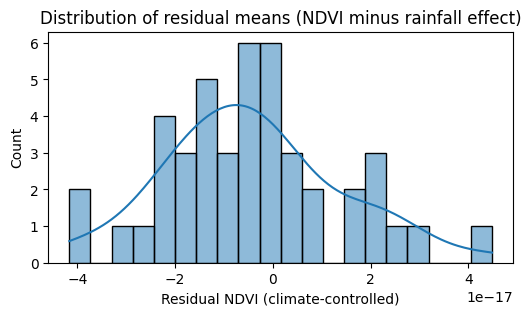

In [10]:
# Merge RESTREND table with hex geometry for mapping
hex_rest = hexes.merge(retrend_bw, on="hex_id", how="left")

# Basic stats table
summary = retrend_bw.describe()
print(summary[["beta_rain_to_ndvi","mk_resid_z","mk_resid_p"]])

# Count of trend types
print(retrend_bw["mk_resid_trend"].value_counts())

# Histogram of residual mean
plt.figure(figsize=(6,3))
sns.histplot(retrend_bw["resid_mean"], bins=20, kde=True)
plt.title("Distribution of residual means (NDVI minus rainfall effect)")
plt.xlabel("Residual NDVI (climate-controlled)")
plt.show()


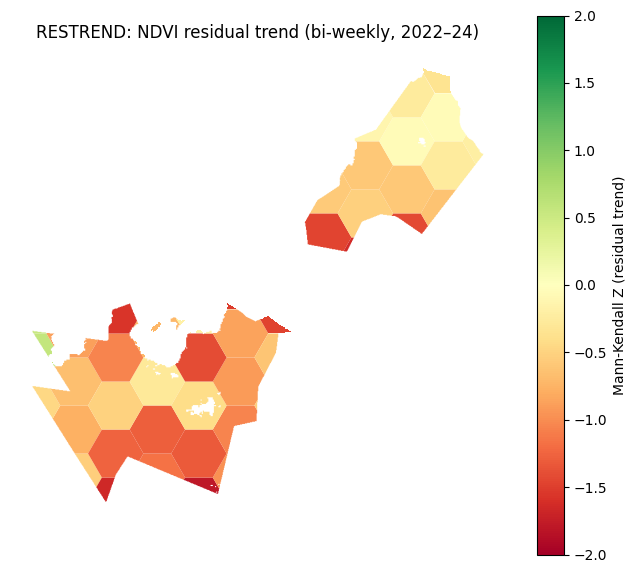

In [27]:
fig, ax = plt.subplots(figsize=(8,7))
hex_rest.plot(column="mk_resid_z", cmap="RdYlGn", legend=True, ax=ax,
              legend_kwds={"label": "Mann-Kendall Z (residual trend)"},
              vmin=-2, vmax=2)
ax.set_title("RESTREND: NDVI residual trend (bi-weekly, 2022–24)")
ax.axis("off")
plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_28592\381944978.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0.1,1,1])


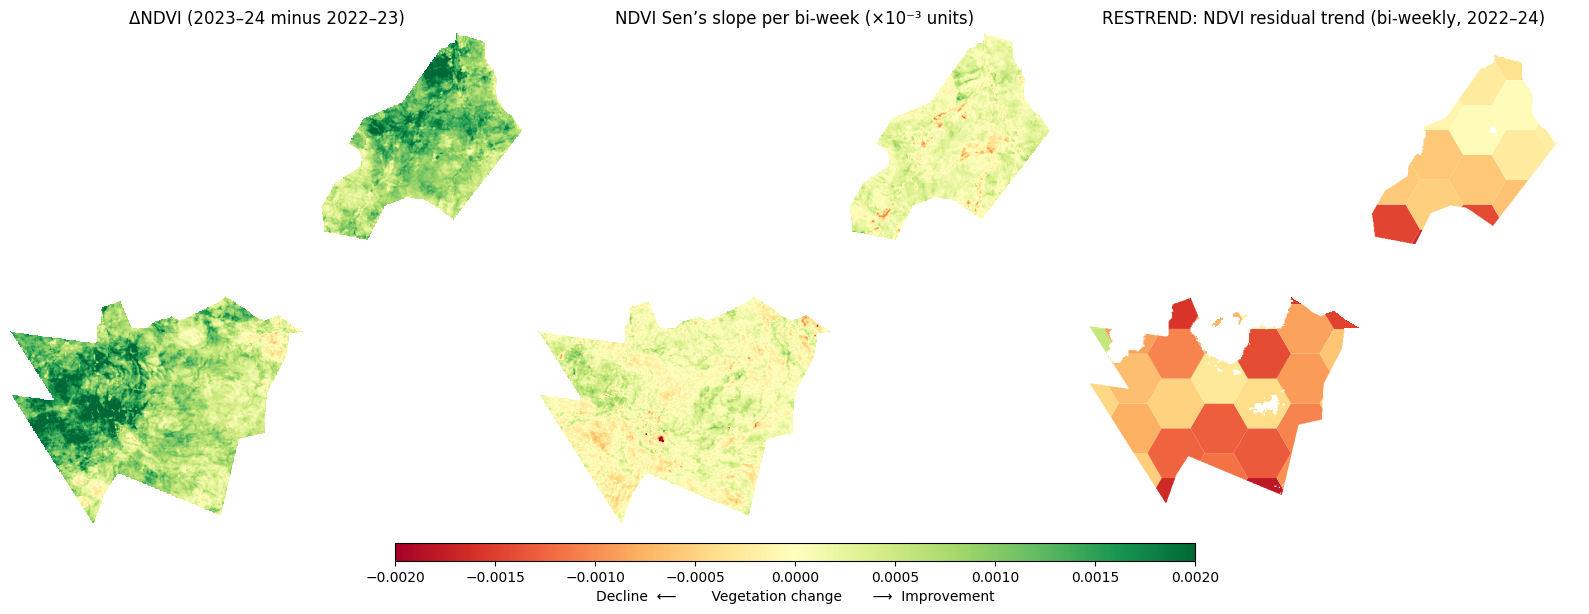

In [29]:
import os
import rasterio
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
from matplotlib.colors import TwoSlopeNorm

# --- Paths ---
delta_ndvi_path = os.path.join(RESULTS, "Delta_NDVI_2023-24_minus_2022-23.tif")
sen_ndvi_path   = os.path.join(RESULTS, "NDVI_MK_SenSlope_Z_P.tif")
hex_retrend_path = os.path.join(RESULTS, "RESTREND_hex1km_biweekly_NDVI_vs_Rain.csv")
hex_grid_path   = os.path.join(RESULTS, "AOI_hexes_1km.geojson")

# --- Load raster layers ---
with rasterio.open(delta_ndvi_path) as src:
    delta_ndvi = src.read(1).astype(float)
    delta_ndvi[delta_ndvi == src.nodata] = np.nan

with rasterio.open(sen_ndvi_path) as src:
    sen_slope = src.read(1).astype(float)
    sen_slope[sen_slope == src.nodata] = np.nan

# --- Load RESTREND hex data ---
hexes = gpd.read_file(hex_grid_path)
retrend = pd.read_csv(hex_retrend_path)
hex_rest = hexes.merge(retrend, on="hex_id", how="left")

# --- Create figure ---
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# ΔNDVI map
im0 = axes[0].imshow(delta_ndvi, cmap="RdYlGn", vmin=-0.2, vmax=0.2)
axes[0].set_title("ΔNDVI (2023–24 minus 2022–23)")
axes[0].axis("off")

# Sen’s slope map
im1 = axes[1].imshow(sen_slope, cmap="RdYlGn", vmin=-0.002, vmax=0.002)
axes[1].set_title("NDVI Sen’s slope per bi-week (×10⁻³ units)")
axes[1].axis("off")

# RESTREND residual trend (Mann–Kendall Z)
norm = TwoSlopeNorm(vmin=-2, vcenter=0, vmax=2)
hex_rest.plot(column="mk_resid_z", ax=axes[2], cmap="RdYlGn", norm=norm, edgecolor="none")
axes[2].set_title("RESTREND: NDVI residual trend (bi-weekly, 2022–24)")
axes[2].axis("off")

# --- Shared colorbar for all ---
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.03])
cb = fig.colorbar(im1, cax=cbar_ax, orientation="horizontal")
cb.set_label("Decline  ⟵        Vegetation change       ⟶  Improvement")

plt.tight_layout(rect=[0,0.1,1,1])
plt.show()


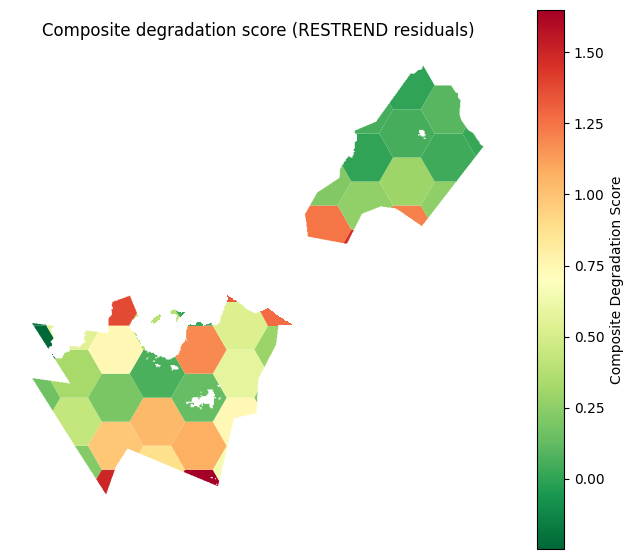

In [34]:
# Normalize relevant fields
z = retrend_bw["mk_resid_z"].clip(-3,3)
p = retrend_bw["mk_resid_p"]
score = (-z) * (1 - p)   # negative trend + significance -> higher score
hex_rest["degrad_score"] = score

# Map composite
fig, ax = plt.subplots(figsize=(8,7))
hex_rest.plot(column="degrad_score", cmap="RdYlGn_r", legend=True, ax=ax,
              legend_kwds={"label": "Composite Degradation Score"})
ax.set_title("Composite degradation score (RESTREND residuals)")
ax.axis("off")
plt.show()


TypeError: unhashable type: 'dict'

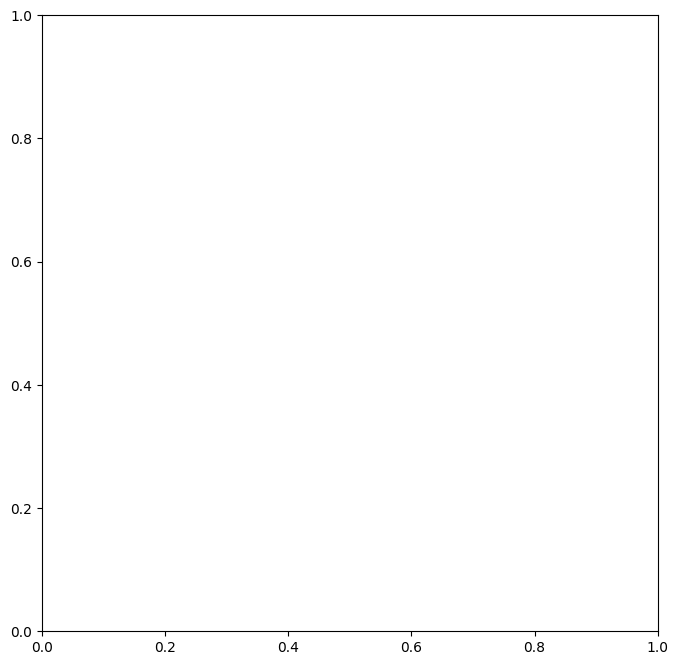

In [3]:
# classify degradation significance
hexes_retrend["degradation_class"] = np.where(
    (hexes_retrend["mk_resid_trend"] == "decreasing") &
    (hexes_retrend["mk_resid_p"] <= 0.1), "Degrading",
    "Stable"
)

# plot
fig, ax = plt.subplots(1, 1, figsize=(8,8))
hexes_retrend.plot(column="degradation_class", ax=ax, legend=True,
                   categorical=True, cmap={"Degrading": "red", "Stable": "lightgray"})
plt.title("RESTREND: NDVI residual trend vs rainfall (bi-weekly)")
plt.axis("off")
plt.show()

# histogram of residual slope
sns.histplot(hexes_retrend["mk_resid_z"].dropna(), bins=20, color="gray")
plt.axvline(0, color="black", linestyle="--")
plt.title("Distribution of RESTREND Z-statistics across hexes")
plt.xlabel("Z (residual trend direction)")
plt.show()
